In [3]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import yfinance as yf
# display and store Matplotlib plots within a Python Jupyter notebook
%matplotlib inline

In [3]:
from scipy.linalg import cholesky
from scipy.stats import norm, linregress

In [5]:
from sklearn.preprocessing import  MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [6]:
import platform
print(f"Python version: {platform.python_version()}")
print(f"Numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
import matplotlib
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"yfinance version: {yf.__version__}")
import sklearn
print(f"sklearn version: {sklearn.__version__}")
#print(f"Pytorch version: {torch.__version__}")
import scipy
print(f"scipy version: {scipy.__version__}")

Python version: 3.10.14
Numpy version: 1.26.4
Pandas version: 2.1.4
Matplotlib version: 3.7.5
Seaborn version: 0.13.2
yfinance version: 0.2.54
sklearn version: 1.6.1
Pytorch version: 2.5.1+cpu
scipy version: 1.11.4


## Simulate the behavior of Brownian motion (BM) and fractional Brownian motion (fBM)

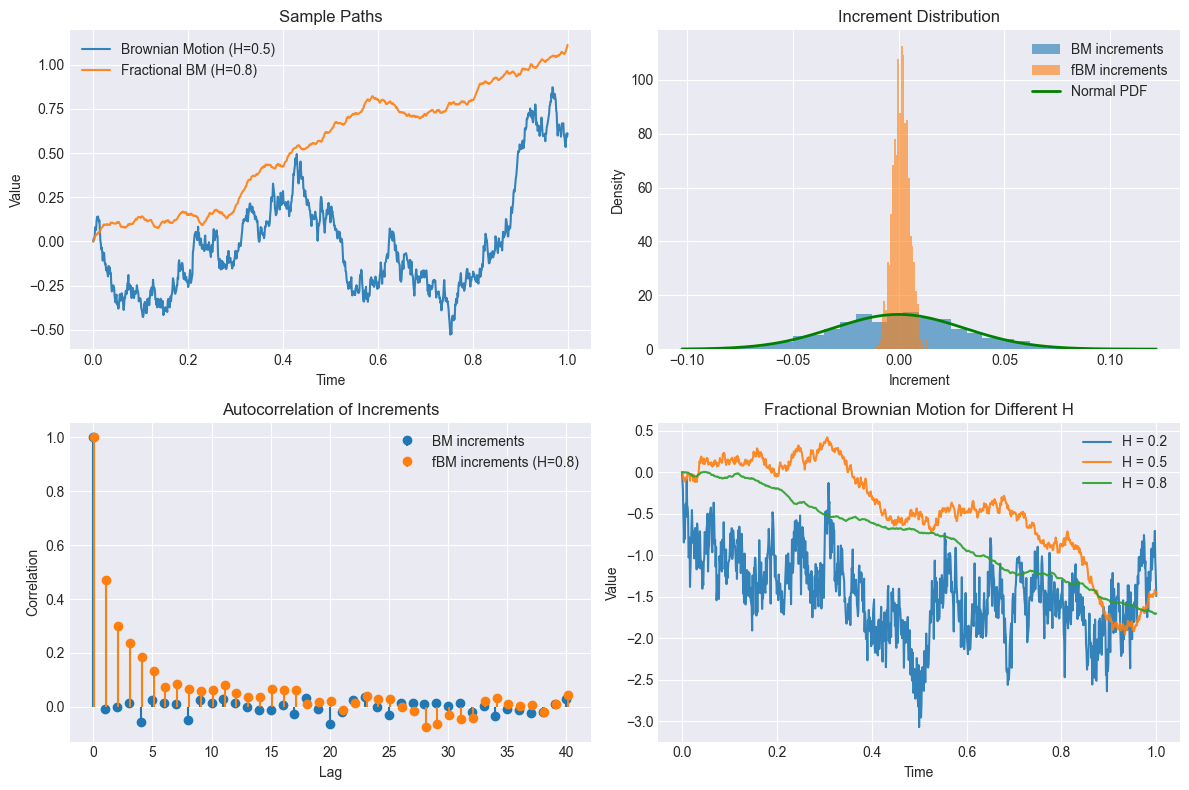

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from fbm import FBM          # pip install fbm
from statsmodels.tsa.stattools import acf  # pip install statsmodels

# -----------------------------
# 1. Parameters
# -----------------------------
T = 1.0          # total time
N = 1000         # number of steps
dt = T / N
t = np.linspace(0, T, N + 1)

np.random.seed(42)

# -----------------------------
# 2. Simulate Brownian Motion (H = 0.5)
# -----------------------------
# Standard BM increments ~ N(0, dt)
bm_increments = np.sqrt(dt) * np.random.randn(N)
bm_path = np.concatenate([[0], np.cumsum(bm_increments)])

# -----------------------------
# 3. Simulate fractional Brownian Motion (H = 0.8)
# -----------------------------
H_fbm = 0.8
fbm_gen = FBM(n=N, hurst=H_fbm, length=T, method='daviesharte')
fbm_path = fbm_gen.fbm()  # length N+1

# fBM increments
fbm_increments = np.diff(fbm_path)

# -----------------------------
# 4. Increment distributions (histograms)
# -----------------------------
# For a fair comparison, use same number of increments
bm_increments_for_hist = bm_increments
fbm_increments_for_hist = fbm_increments

# -----------------------------
# 5. Autocorrelation of increments
# -----------------------------
max_lag = 40

bm_acf = acf(bm_increments_for_hist, nlags=max_lag, fft=True)
fbm_acf = acf(fbm_increments_for_hist, nlags=max_lag, fft=True)
lags = np.arange(max_lag + 1)

# -----------------------------
# 6. fBM for different H values
# -----------------------------
H_values = [0.2, 0.5, 0.8]
fbm_paths_H = {}

for H in H_values:
    fbm_gen_H = FBM(n=N, hurst=H, length=T, method='daviesharte')
    fbm_paths_H[H] = fbm_gen_H.fbm()

# -----------------------------
# 7. Plotting
# -----------------------------
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ax1, ax2, ax3, ax4 = axes.ravel()

# ---- Top-left: Sample Paths (BM vs fBM H=0.8) ----
ax1.plot(t, bm_path, label='Brownian Motion (H=0.5)', color='tab:blue', alpha=0.9)
ax1.plot(t, fbm_path, label='Fractional BM (H=0.8)', color='tab:orange', alpha=0.9)
ax1.set_title('Sample Paths')
ax1.set_xlabel('Time')
ax1.set_ylabel('Value')
ax1.legend(loc='best')

# ---- Top-right: Increment Distribution ----
bins = 30
ax2.hist(bm_increments_for_hist, bins=bins, density=True, alpha=0.6,
         label='BM increments', color='tab:blue')
ax2.hist(fbm_increments_for_hist, bins=bins, density=True, alpha=0.6,
         label='fBM increments', color='tab:orange')

# Overlay normal density for reference
from scipy.stats import norm
x_vals = np.linspace(
    min(bm_increments_for_hist.min(), fbm_increments_for_hist.min()),
    max(bm_increments_for_hist.max(), fbm_increments_for_hist.max()),
    200
)
mu = 0.0
sigma = np.std(bm_increments_for_hist)  # use BM std as reference
ax2.plot(x_vals, norm.pdf(x_vals, mu, sigma), color='green', lw=2, label='Normal PDF')

ax2.set_title('Increment Distribution')
ax2.set_xlabel('Increment')
ax2.set_ylabel('Density')
ax2.legend(loc='best')

# ---- Bottom-left: Autocorrelation of Increments ----
ax3.stem(lags, bm_acf, linefmt='tab:blue', markerfmt='o', basefmt=' ', label='BM increments', use_line_collection=True)
ax3.stem(lags + 0.1, fbm_acf, linefmt='tab:orange', markerfmt='o', basefmt=' ', label='fBM increments (H=0.8)', use_line_collection=True)

ax3.set_title('Autocorrelation of Increments')
ax3.set_xlabel('Lag')
ax3.set_ylabel('Correlation')
ax3.legend(loc='best')

# ---- Bottom-right: fBM for Different H ----
colors = {0.2: 'tab:blue', 0.5: 'tab:orange', 0.8: 'tab:green'}
for H in H_values:
    ax4.plot(t, fbm_paths_H[H], label=f'H = {H}', color=colors[H], alpha=0.9)

ax4.set_title('Fractional Brownian Motion for Different H')
ax4.set_xlabel('Time')
ax4.set_ylabel('Value')
ax4.legend(loc='best')

plt.tight_layout()
plt.savefig("./Documents/Bm-fBm2.png")
plt.show()


## Rescaled Range (R/S) Analysis and Detrended Fluctuation Analysis for S&P500

Loading S&P 500 data...
Observations: 6659 prices, 6658 returns
Period: 2000-01-03 to 2026-06-26
Scale range: 16 <= n <= 554
Number of unique log‑spaced scales = 20
Scale list: [ 16  19  23  28  34  41  49  59  71  86 103 125 150 181 218 263 317 381
 460 554]





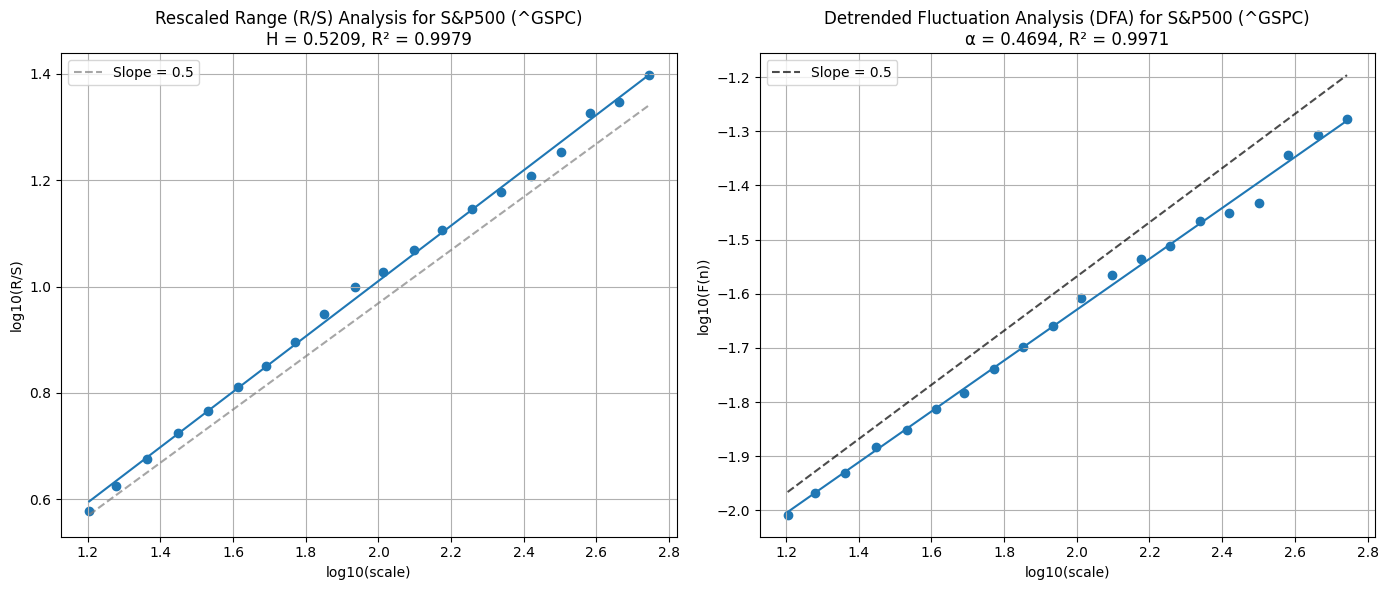


R/S Analysis for S&P500 (^GSPC)
Hurst H  = 0.5209
R²       = 0.9979

DFA for S&P500 (^GSPC)
Alpha α  = 0.4694
R²       = 0.9971

Relationship
For stationary log-return data:
    H ≈ α
Difference = 0.0515

Interpretation
[Combined H + α Interpretation]
H ≈ 0.5209 → persistent
α ≈ 0.4694 → anti-correlated (anti-persistent)

Mixed signals: R/S and DFA disagree.
- This usually indicates weak long-memory
- Or non-stationarity / volatility clustering
- Or estimator sensitivity to scale choices

Interpretation guide (Hurst exponent H):
  H < 0.5  → Anti-persistent (mean-reverting)
  H = 0.5  → Brownian motion (random walk)
  H > 0.5  → Persistent (trend-following)

Interpretation guide (DFA scaling exponent α):
  α < 0.5  → Anti-correlated (mean-reverting)
  α = 0.5  → Uncorrelated white noise
  α > 0.5  → Positively correlated (persistent)
  α = 1.5  → Brownian noise (integrated white noise)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import linregress

# ==========================================================
# Download SP500
# ==========================================================

# Load data
print("Loading S&P 500 data...")

ticker = "^GSPC"
data = yf.download(ticker, start="2000-01-01", progress=False)
data.columns = data.columns.get_level_values(0)
data.columns = [''.join(col).strip() for col in data.columns.values]
close = data["Close"].dropna()

# Log returns
r = np.log(close / close.shift(1)).dropna().values

N = len(r)

print(f"Observations: {len(close)} prices, {len(r)} returns")
print(f"Period: {data.index[0].date()} to {data.index[-1].date()}")



# ==========================================================
# Common scales used by BOTH methods
# ==========================================================

MIN_SCALE = 16
MAX_SCALE = N // 12

scales = np.unique(
    np.round(
        np.logspace(
            np.log10(MIN_SCALE),
            np.log10(MAX_SCALE),
            20
        )
    ).astype(int)
)

print(f"Scale range: {MIN_SCALE} <= n <= {MAX_SCALE}")
print(f"Number of unique log‑spaced scales = {len(scales)}")
print(f"Scale list: {scales}")
print("\n\n")

def rs_analysis(x,
                scales,
                min_windows=8):
    """
    Rescaled Range (R/S) Analysis to estimate the Hurst exponent H.

    Parameters
    ----------
    x : 1-D array-like
        Input time series (e.g., log-returns).
    scales : array-like
        Window sizes (scales) to evaluate.
    min_windows : int, default 8
        Minimum number of non-overlapping windows required for a scale
        to be included in the regression.

    Returns
    -------
    dict
        scales      : array of valid scales used
        RSvalues    : mean R/S for each scale
        H           : Hurst exponent (slope of log(R/S) vs log(scale))
        R2          : coefficient of determination of the fit
        intercept   : intercept of the regression line

    Interpretation of H (Hurst exponent):
    -------------------------------------
    H < 0.5  → Anti-persistent (mean-reverting) process
    H = 0.5  → Brownian motion / random walk (uncorrelated)
    H > 0.5  → Persistent (trend-following) process
    """

    N = len(x)
    rs_values = []
    valid_scales = []
    for n in scales:
        num_windows = N // n
        if num_windows < min_windows:
            continue
        rs_window = []
        for i in range(num_windows):
            segment = x[i*n:(i+1)*n]
            mean_seg = np.mean(segment)
            y = np.cumsum(segment - mean_seg)
            R = np.max(y) - np.min(y)
            S = np.std(segment, ddof=1)
            if S > 0:
                rs_window.append(R / S)

        if rs_window:
            valid_scales.append(n)
            rs_values.append(np.mean(rs_window))

    valid_scales = np.array(valid_scales)
    rs_values = np.array(rs_values)

    x_reg = np.log10(valid_scales)
    y_reg = np.log10(rs_values)

    slope, intercept, r_value, _, _ = linregress(
        x_reg,
        y_reg
    )

    return {
        "scales": valid_scales,
        "RSvalues": rs_values,
        "H": slope,
        "R2": r_value**2,
        "intercept": intercept
    }

def dfa(x,
        scales,
        min_windows=8):
    """
    Detrended Fluctuation Analysis (DFA) to estimate the scaling exponent α.

    Parameters
    ----------
    x : 1-D array-like
        Input time series (e.g., log-returns).
    scales : array-like
        Window sizes (scales) to evaluate.
    min_windows : int, default 8
        Minimum number of non-overlapping windows required for a scale
        to be included in the regression.

    Returns
    -------
    dict
        scales      : array of valid scales used
        Fvalues     : mean fluctuation for each scale
        alpha       : scaling exponent (slope of log(F) vs log(scale))
        R2          : coefficient of determination of the fit
        intercept   : intercept of the regression line

    Interpretation of α (DFA scaling exponent):
    --------------------------------------------
    α < 0.5  → Anti-correlated (mean-reverting) process
    α = 0.5  → Uncorrelated white noise
    0.5 < α < 1.0 → Positively correlated (persistent) process
    α = 1.0  → 1/f noise (pink noise)
    α = 1.5  → Brownian noise (integrated white noise)
    α > 1.5  → Non-stationary / strongly correlated process
    """

    N = len(x)
    profile = np.cumsum(x - np.mean(x))

    F_values = []
    valid_scales = []

    for n in scales:
        num_windows = N // n
        if num_windows < min_windows:
            continue
        flucts = []
        for i in range(num_windows):
            segment = profile[i*n:(i+1)*n]
            t = np.arange(n)
            coeffs = np.polyfit(t, segment, 1)
            trend = np.polyval(coeffs, t)
            rms = np.sqrt(
                np.mean(
                    (segment - trend)**2
                )
            )

            flucts.append(rms)

        if flucts:
            valid_scales.append(n)
            F_values.append(np.mean(flucts))

    valid_scales = np.array(valid_scales)
    F_values = np.array(F_values)

    x_reg = np.log10(valid_scales)
    y_reg = np.log10(F_values)

    slope, intercept, r_value, _, _ = linregress(
        x_reg,
        y_reg
    )

    return {
        "scales": valid_scales,
        "Fvalues": F_values,
        "alpha": slope,
        "R2": r_value**2,
        "intercept": intercept
    }

# ---------------------------------------------------------
#  Interpretation helpers
# ---------------------------------------------------------
def interpret_H_and_alpha(H, alpha):
    """
    Combined interpretation of Hurst exponent (R/S) and DFA alpha.

    Classification thresholds (based on standard theory):
    -----------------------------------------------------
    H (Hurst exponent):
        H < 0.5  → Anti-persistent (mean-reverting)
        H = 0.5  → Brownian motion (random walk)
        H > 0.5  → Persistent (trend-following)

    α (DFA scaling exponent):
        α < 0.5  → Anti-correlated (mean-reverting)
        α = 0.5  → Uncorrelated white noise
        α > 0.5  → Positively correlated (persistent)
        α = 1.5  → Brownian noise (integrated white noise)
    """

    # Handle NaN cases
    if np.isnan(H) and np.isnan(alpha):
        return "Both H and α are NaN: insufficient data or numerical issue."
    if np.isnan(H):
        return "H is NaN; α interpretation only.\n" + interpret_DFA_alpha(alpha)
    if np.isnan(alpha):
        return "α is NaN; H interpretation only.\n" + interpret_statistical_Hurst(H)

    # Classify H using the standard thresholds: H < 0.5 anti-persistent, H = 0.5 Brownian, H > 0.5 persistent
    if H > 0.5:
        H_regime = "persistent"
    elif H < 0.5:
        H_regime = "anti-persistent"
    else:
        H_regime = "Brownian (random walk)"

    # Classify α using the standard thresholds: α < 0.5 anti-correlated, α = 0.5 white noise, α > 0.5 positively correlated
    if alpha > 0.5:
        A_regime = "persistent (positively correlated)"
    elif alpha < 0.5:
        A_regime = "anti-correlated (anti-persistent)"
    else:
        A_regime = "uncorrelated white noise"

    # Combined logic
    if H_regime == A_regime.split(" ")[0]:
        combined = f"Both estimators agree: {H_regime} behavior."
    else:
        combined = (
            "Mixed signals: R/S and DFA disagree.\n"
            "- This usually indicates weak long-memory\n"
            "- Or non-stationarity / volatility clustering\n"
            "- Or estimator sensitivity to scale choices"
        )

    # Build message
    msg = (
        f"[Combined H + α Interpretation]\n"
        f"H ≈ {H:.4f} → {H_regime}\n"
        f"α ≈ {alpha:.4f} → {A_regime}\n"
        f"\n{combined}\n"
        f"\nInterpretation guide (Hurst exponent H):\n"
        f"  H < 0.5  → Anti-persistent (mean-reverting)\n"
        f"  H = 0.5  → Brownian motion (random walk)\n"
        f"  H > 0.5  → Persistent (trend-following)\n"
        f"\nInterpretation guide (DFA scaling exponent α):\n"
        f"  α < 0.5  → Anti-correlated (mean-reverting)\n"
        f"  α = 0.5  → Uncorrelated white noise\n"
        f"  α > 0.5  → Positively correlated (persistent)\n"
        f"  α = 1.5  → Brownian noise (integrated white noise)\n"
    )

    return msg

# ==========================================================
# Run analyses
# ==========================================================
rs_result = rs_analysis(
    r,
    scales,
    min_windows=8
)

dfa_result = dfa(
    r,
    scales,
    min_windows=8
)

# Create a single figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ==========================================================
# Plot 1: R/S Analysis (Left Subplot)
# ==========================================================
ax1 = axes[0]
x_rs = np.log10(rs_result["scales"])
y_rs = np.log10(rs_result["RSvalues"])

# Reference line with slope = 0.5 (using its own intercept to align with data)
y_ref_rs = rs_result["intercept"] + 0.5 * x_rs
ax1.plot(x_rs, y_ref_rs, color="gray", linestyle="--", alpha=0.7, label="Slope = 0.5")

ax1.scatter(x_rs, y_rs)
ax1.plot(x_rs, rs_result["intercept"] + rs_result["H"] * x_rs)
ax1.set_xlabel("log10(scale)")
ax1.set_ylabel("log10(R/S)")
ax1.set_title(
    f"Rescaled Range (R/S) Analysis for S&P500 (^GSPC)\n" f"H = {rs_result['H']:.4f}, " f"R² = {rs_result['R2']:.4f}"
)
ax1.grid(True)
ax1.legend()

# ==========================================================
# Plot 2: DFA (Right Subplot)
# ==========================================================
ax2 = axes[1]
x_dfa = np.log10(dfa_result["scales"])
y_dfa = np.log10(dfa_result["Fvalues"])

# Reference line with slope = 0.5 (using its own intercept to align with data)
y_ref_dfa = dfa_result["intercept"] + 0.5 * x_dfa
ax2.plot(x_dfa, y_ref_dfa, color="black", linestyle="--", alpha=0.7, label="Slope = 0.5")

ax2.scatter(x_dfa, y_dfa)
ax2.plot(x_dfa, dfa_result["intercept"] + dfa_result["alpha"] * x_dfa)
ax2.set_xlabel("log10(scale)")
ax2.set_ylabel("log10(F(n))")
ax2.set_title(
    f"Detrended Fluctuation Analysis (DFA) for S&P500 (^GSPC)\n" f"α = {dfa_result['alpha']:.4f}, " f"R² = {dfa_result['R2']:.4f}"
)
ax2.grid(True)
ax2.legend()

# Adjust layout and display
plt.tight_layout()
plt.savefig("./Documents/RS-DFA.png")
plt.show()

# ==========================================================
# Summary
# ==========================================================

print("\n==============================")
print("R/S Analysis for S&P500 (^GSPC)")
print("==============================")
print(f"Hurst H  = {rs_result['H']:.4f}")
print(f"R²       = {rs_result['R2']:.4f}")

print("\n==============================")
print("DFA for S&P500 (^GSPC)")
print("==============================")
print(f"Alpha α  = {dfa_result['alpha']:.4f}")
print(f"R²       = {dfa_result['R2']:.4f}")

print("\n==============================")
print("Relationship")
print("==============================")
print("For stationary log-return data:")
print("    H ≈ α")
print(f"Difference = {abs(rs_result['H'] - dfa_result['alpha']):.4f}")

print("\n==============================")
print("Interpretation")
print("==============================")
print(interpret_H_and_alpha(rs_result['H'], dfa_result['alpha']))